In [1]:
import numpy as np

from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

k = 1
field_size = 40

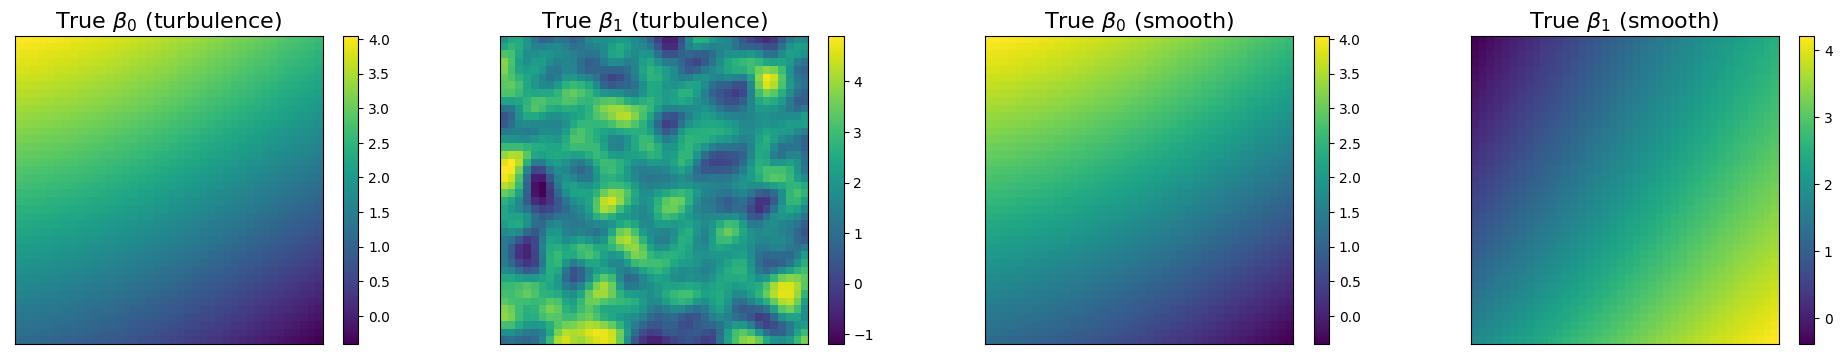

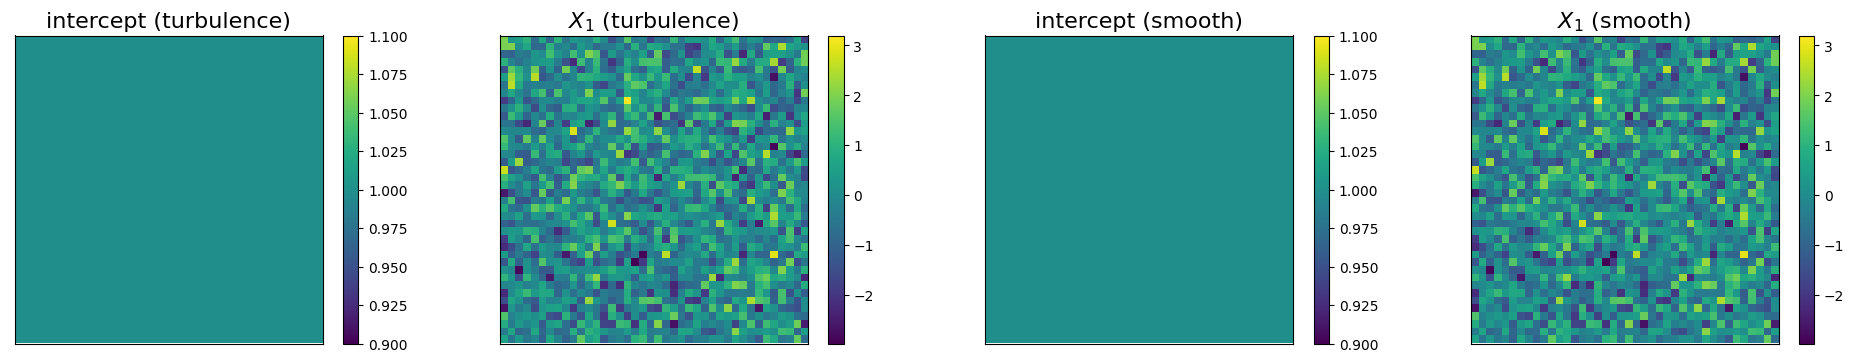

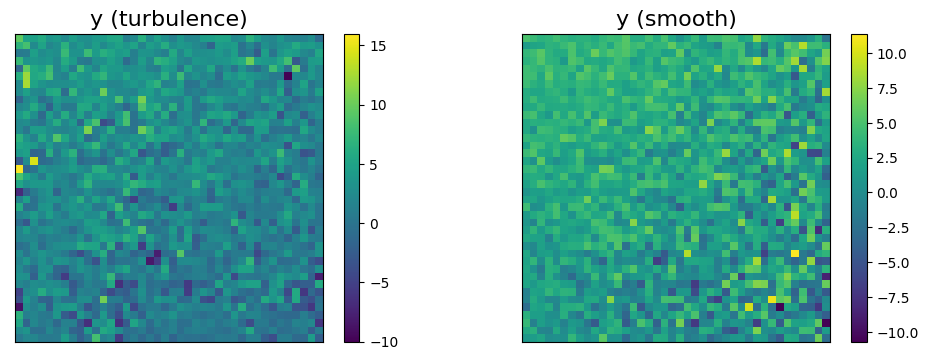

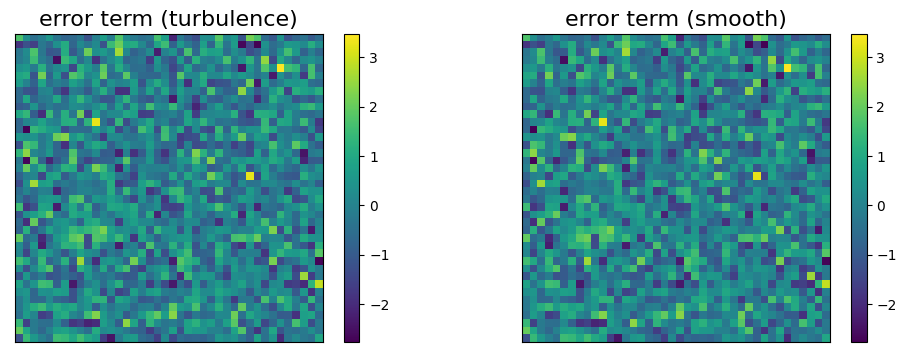

In [2]:

dataset_turbulence = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 2]
)
[X_turbulence] = dataset_turbulence.generate_data()
[beta_turbulence] = dataset_turbulence.generate_processes()
[y_turbulence, err_turbulence] = dataset_turbulence.fit_y(
    X_turbulence, beta_turbulence
)

dataset_smooth = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 100]
)
[X_smooth] = dataset_smooth.generate_data()
[beta_smooth] = dataset_smooth.generate_processes()
[y_smooth, err_smooth] = dataset_smooth.fit_y(
    X_smooth, beta_smooth
)


dataset_turbulence.plot(
    b=np.vstack([beta_turbulence.T, beta_smooth.T]),
    sub_title=[
        r"True $\beta_0$ (turbulence)", 
        r"True $\beta_1$ (turbulence)", 
        r"True $\beta_0$ (smooth)",
        r"True $\beta_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([X_turbulence.T, X_smooth.T]),
    sub_title=[
        r"intercept (turbulence)", 
        r"$X_1$ (turbulence)", 
        r"intercept (smooth)", 
        r"$X_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([y_turbulence.reshape(1, -1), y_smooth.reshape(1, -1)]),
    sub_title=['y (turbulence)', 'y (smooth)'],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([err_turbulence.reshape(1, -1), err_smooth.reshape(1, -1)]),
    sub_title=['error term (turbulence)', 'error term (smooth)'],
    size=field_size
)

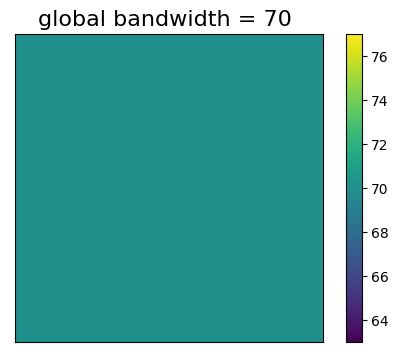

In [3]:


dataset_turbulence.plot(
    b=np.full(dataset_turbulence.n, 70).reshape(1, -1),
    sub_title=['global bandwidth = 70 '],
    size=field_size
)

use golden search to find a global optimal bandwidth

In [4]:
g_X_turbulence = dataset_turbulence.X[:, 1:]
g_y_turbulence = dataset_turbulence.y.reshape(-1, 1)
g_coords_turbulence = dataset_turbulence.coordinates.tolist()

gwr_selector_turbulence = Sel_BW(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence
)
gwr_bw_turbulence = gwr_selector_turbulence.search(bw_min=2)
official_gwr_turbulence = OfficialGWR(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence, 
    gwr_bw_turbulence
).fit()


g_X_smooth = dataset_smooth.X[:, 1:]
g_y_smooth = dataset_smooth.y.reshape(-1, 1)
g_coords_smooth = dataset_smooth.coordinates.tolist()
gwr_selector_smooth = Sel_BW(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth
)
gwr_bw_smooth = gwr_selector_smooth.search(bw_min=2)
official_gwr_smooth = OfficialGWR(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth, 
    gwr_bw_smooth
).fit()

In [5]:
# formatted comparison between the two official GWR fits
print("="*60)
print("GWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Turbulence':>12} {'Smooth':>15}")
print("-"*60)
print(f"{'Global bandwidth':30} {int(gwr_bw_turbulence):12d} {int(gwr_bw_smooth):15d}")
print(f"{'R-squared':30} {official_gwr_turbulence.R2:12.4f} {official_gwr_smooth.R2:15.4f}")
print(f"{'AIC':30} {official_gwr_turbulence.aic:12.2f} {official_gwr_smooth.aic:15.2f}")
print(f"{'AICc':30} {official_gwr_turbulence.aicc:12.2f} {official_gwr_smooth.aicc:15.2f}")
print("-"*60)
print("="*60)

GWR Model Comparison
Metric                           Turbulence          Smooth
------------------------------------------------------------
Global bandwidth                         44             186
R-squared                            0.8687          0.8687
AIC                                 4875.78         4514.41
AICc                                4942.36         4517.47
------------------------------------------------------------


Reload LGWR log files

In [6]:
from src.reload.lgwr_reload import reload_logs, reload_lgwr

bandwidth_sets_smooth = reload_logs(r"./logs/one-beta-lgwr/smooth/model_info.json")
bandwidth_sets_turbulence = reload_logs(r"./logs/one-beta-lgwr/turbulence/model_info.json")

In [10]:
lower_aicc_smooth_bw_sets = []
for bw_set in bandwidth_sets_smooth:
    if float(bw_set["reward"]) <= official_gwr_smooth.aicc:
        lower_aicc_smooth_bw_sets.append(bw_set)

lower_aicc_turbulence_bw_sets = []
for bw_set in bandwidth_sets_turbulence:
    if float(bw_set["reward"]) <= official_gwr_turbulence.aicc:
        lower_aicc_turbulence_bw_sets.append(bw_set)

print(f"smooth: {len(lower_aicc_smooth_bw_sets)} / {len(bandwidth_sets_smooth)}")
print(f"turbulence: {len(lower_aicc_turbulence_bw_sets)} / {len(bandwidth_sets_turbulence)}")

smooth: 645 / 729
turbulence: 620 / 726


In [ ]:
best_bw_set_smooth = min(lower_aicc_smooth_bw_sets, key=lambda s: float(s['reward']))
print(f"best smooth episode: {best_bw_set_smooth['episode']}, reward: {best_bw_set_smooth['reward']}, r2: {best_bw_set_smooth.get('r2')}")
best_bw = best_bw_set_smooth['bandwidth']

best_bw_set_turbulence = min(lower_aicc_turbulence_bw_sets, key=lambda s: float(s['reward']))
print(f"best turbulence episode: {best_bw_set_turbulence['episode']}, reward: {best_bw_set_turbulence['reward']}, r2: {best_bw_set_turbulence.get('r2')}")
best_bw = best_bw_set_turbulence['bandwidth']

best smooth episode: 662, reward: 4507.9113598112, r2: 0.8703476728193946
best turbulence episode: 725, reward: 4914.812341248852, r2: 0.8684777818147513


In [18]:
lgwr_smooth = reload_lgwr(dataset_smooth, best_bw_set_smooth)
lgwr_turbulence = reload_lgwr(dataset_turbulence, best_bw_set_turbulence)

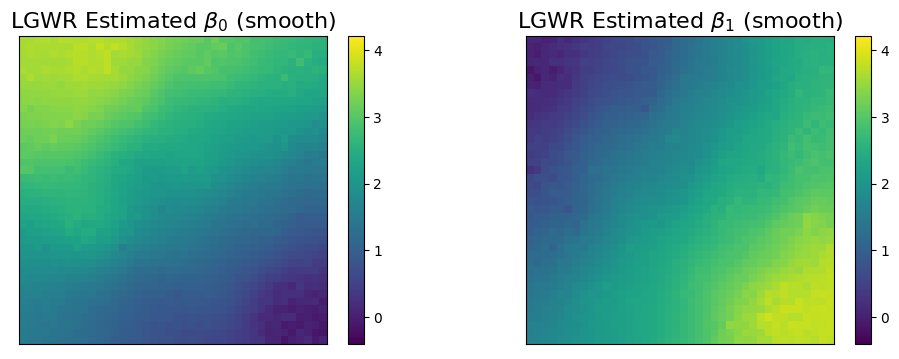

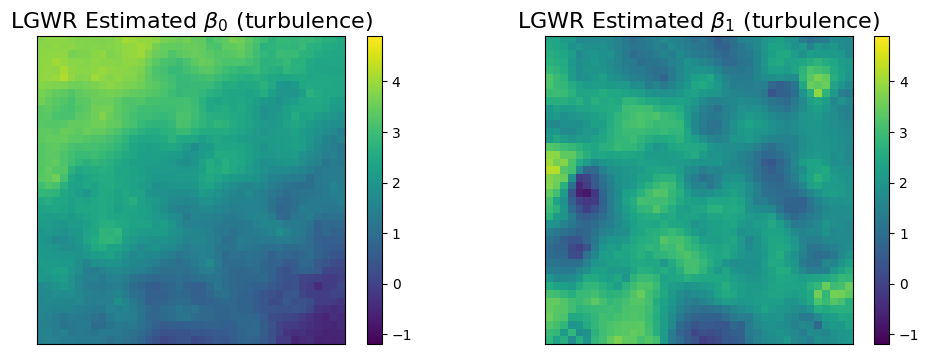

In [22]:
dataset_smooth.plot(
    b=lgwr_smooth.betas.T,
    sub_title=[
        r"LGWR Estimated $\beta_0$ (smooth)", 
        r"LGWR Estimated $\beta_1$ (smooth)"
    ],
    size=field_size,
    vmin=beta_smooth.min(), vmax=beta_smooth.max()
)

dataset_turbulence.plot(
    b=lgwr_turbulence.betas.T,
    sub_title=[
        r"LGWR Estimated $\beta_0$ (turbulence)", 
        r"LGWR Estimated $\beta_1$ (turbulence)"
    ],
    size=field_size,
    vmin=beta_turbulence.min(), vmax=beta_turbulence.max()
)

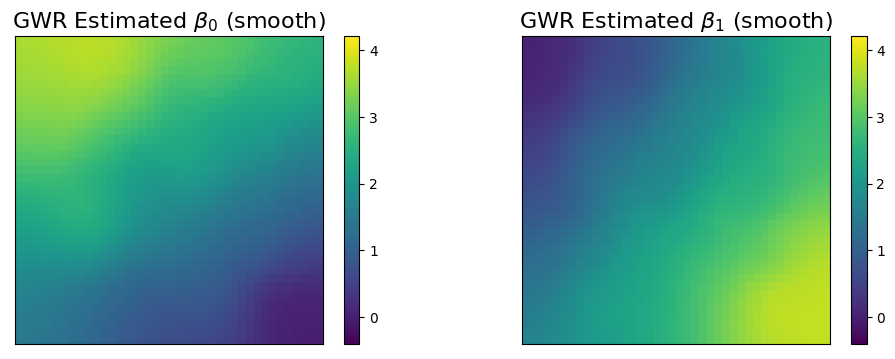

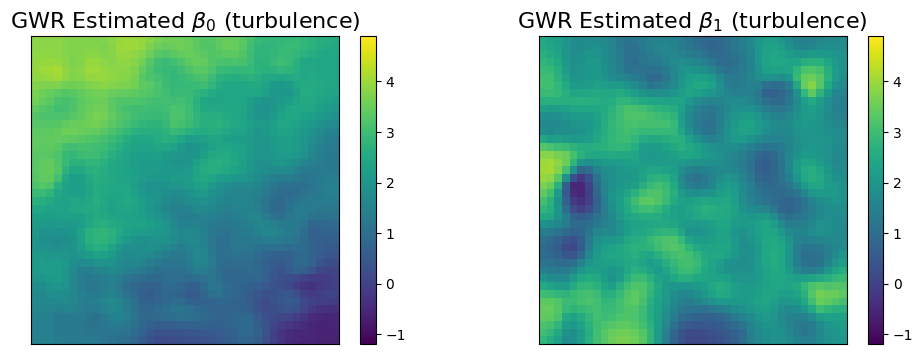

In [33]:
dataset_smooth.plot(
    b=official_gwr_smooth.params.T,
    sub_title=[
        r"GWR Estimated $\beta_0$ (smooth)", 
        r"GWR Estimated $\beta_1$ (smooth)"
    ],
    size=field_size,
    vmin=beta_smooth.min(), vmax=beta_smooth.max()
)

dataset_turbulence.plot(
    b=official_gwr_turbulence.params.T,
    sub_title=[
        r"GWR Estimated $\beta_0$ (turbulence)", 
        r"GWR Estimated $\beta_1$ (turbulence)"
    ],
    size=field_size,
    vmin=beta_turbulence.min(), vmax=beta_turbulence.max()
)

In [32]:
print(lgwr_smooth.betas.shape)
print(lgwr_turbulence.betas.shape)

print(official_gwr_smooth.params.shape)
print(official_gwr_turbulence.params.shape)

def _align(true, est):
    est = np.asarray(est)
    if est.shape == true.shape:
        return est
    if est.T.shape == true.shape:
        return est.T
    try:
        return est.reshape(true.shape)
    except Exception as e:
        raise ValueError(f"Cannot align shapes true:{true.shape} est:{est.shape}") from e

# Smooth
true_smooth = np.asarray(beta_smooth)
lgwr_smooth_est = _align(true_smooth, lgwr_smooth.betas)
gwr_smooth_est = _align(true_smooth, official_gwr_smooth.params)

mse_lgwr_smooth_per_param = np.mean((true_smooth - lgwr_smooth_est) ** 2, axis=0)
mse_lgwr_smooth_overall = np.mean((true_smooth - lgwr_smooth_est) ** 2)

mse_gwr_smooth_per_param = np.mean((true_smooth - gwr_smooth_est) ** 2, axis=0)
mse_gwr_smooth_overall = np.mean((true_smooth - gwr_smooth_est) ** 2)

# Turbulence
true_turb = np.asarray(beta_turbulence)
lgwr_turb_est = _align(true_turb, lgwr_turbulence.betas)
gwr_turb_est = _align(true_turb, official_gwr_turbulence.params)

mse_lgwr_turb_per_param = np.mean((true_turb - lgwr_turb_est) ** 2, axis=0)
mse_lgwr_turb_overall = np.mean((true_turb - lgwr_turb_est) ** 2)

mse_gwr_turb_per_param = np.mean((true_turb - gwr_turb_est) ** 2, axis=0)
mse_gwr_turb_overall = np.mean((true_turb - gwr_turb_est) ** 2)

# Print results
print("Smooth:")
print("  LGWR mse per param:", mse_lgwr_smooth_per_param)
print("  LGWR mse overall:   {:.6e}".format(mse_lgwr_smooth_overall))
print("  GWR  mse per param:", mse_gwr_smooth_per_param)
print("  GWR  mse overall:   {:.6e}".format(mse_gwr_smooth_overall))
print()
print("Turbulence:")
print("  LGWR mse per param:", mse_lgwr_turb_per_param)
print("  LGWR mse overall:   {:.6e}".format(mse_lgwr_turb_overall))
print("  GWR  mse per param:", mse_gwr_turb_per_param)
print("  GWR  mse overall:   {:.6e}".format(mse_gwr_turb_overall))


(1600, 2)
(1600, 2)
(1600, 2)
(1600, 2)
Smooth:
  LGWR mse per param: [0.01528602 0.01610088]
  LGWR mse overall:   1.569345e-02
  GWR  mse per param: [0.01405016 0.01511131]
  GWR  mse overall:   1.458074e-02

Turbulence:
  LGWR mse per param: [0.05517473 0.34947064]
  LGWR mse overall:   2.023227e-01
  GWR  mse per param: [0.05811215 0.32057523]
  GWR  mse overall:   1.893437e-01
